# Testinground
Notebook de pruebas diagnósticas para modelos DL (MLP, NODE).
No modificar el pipeline principal.

In [1]:
import os
import sys
import tempfile
import warnings
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from loguru import logger

# Resolve workspace root (notebook CWD is notebooks/, root is one level up)
ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from src.models.dltab.regressor     import DLTabularRegressor
from src.models.dltab.data.datasets import LEMONscDataManager
from src.processing.features        import filter_simulation_artifacts, tabular_features
from src.processing.scalers         import TargetTransform
from src.utils.resources            import set_numpy_torch_seed
from src.utils.eval                 import compute_metrics
from jobs.config._dltab             import JobConfig

warnings.filterwarnings("ignore", category=UserWarning)
logger.remove()
logger.add(sink=sys.stdout, level="INFO", format="<level>{level}: {message}</level>")

print(f"Workspace root : {ROOT}")
print(f"Device         : {'cuda' if torch.cuda.is_available() else 'cpu'}")


Workspace root : /workspace
Device         : cuda


## Configuración base
Parámetros y features que coinciden con el training más reciente (`training_results_20260508_084316`).

In [2]:
CONFIG = JobConfig()
DEVICE = CONFIG.device
SEED   = CONFIG.seed
FOLD   = 0  # Diagnóstico sobre fold 0 únicamente

# Paths derivados del workspace root (evita problemas de CWD)
FEATS_PATH = ROOT / "datasets/paperv5/moccasurvey"

TARGET_COL      = "log(M_MMO/M_tot)"
TARGET_NORM_COL = "M_tot"

CONT_FEATS = [
    "log(t/t_cc)", "log(t/t_relax)", "log(t/t_cross)", "log(t/t_coll)",
    "log(M_tot)", "log(M_MMO_0)",
    "log(R_h/R_core)", "log(R_tid/R_core)",
    "log(rho(R_h))", "log(Z)", "log(fbin)"
]
CAT_FEATS     = []
FEATURE_COLS  = CONT_FEATS
FEATURE_NAMES = CONT_FEATS + [TARGET_COL]

# Best hyperparams from training_results_20260508_084316 (Optuna)
BEST_PARAMS = {
    "optimizer_params"    : {"lr": 0.0006648342839343055, "weight_decay": 2.21007447731129e-05},
    "loss_params"         : {"delta": 0.95},
    "architecture_params" : {"activation": "silu", "dropout": 0.1, "normalization": "batch"}
}

MAX_EPOCHS  = 100
ES_PATIENCE = 15
BATCH_SIZE  = CONFIG.dataconfig.batch_size

# Verify paths exist
assert FEATS_PATH.exists(), f"FEATS_PATH not found: {FEATS_PATH}"
assert (FEATS_PATH / f"{FOLD}_fold" / "train.csv").exists(), f"Fold {FOLD} train.csv not found"

print(f"Fold: {FOLD} | Device: {DEVICE} | Batch size: {BATCH_SIZE}")
print(f"FEATS_PATH: {FEATS_PATH}")


Fold: 0 | Device: cuda | Batch size: 4096
FEATS_PATH: /workspace/datasets/paperv5/moccasurvey


## Carga de datos — Fold 0

In [39]:
fold_seed = set_numpy_torch_seed(seed_num=SEED, idx=FOLD)

transform_fn = lambda df: tabular_features(
    filter_simulation_artifacts(
        df,
        min_denominator_threshold = CONFIG.dataconfig.min_dem_thr,
        filter_null_mass     = True,
        filter_initial_state = False,
        verbose              = False
    ),
    names                      = FEATURE_NAMES,
    return_names               = False,
    eps_logscale_all_range     = CONFIG.scalingconfig.feature_log_eps_all_range,
    eps_logscale_limited_range = CONFIG.scalingconfig.feature_log_eps_lim_range
)

scaler_kwargs = {
    "feats"  : {"scaler_name": CONFIG.scalingconfig.feature_scaler_name, "scaler_kwargs": {}},
    "target" : {"scaler_name": CONFIG.scalingconfig.target_scaler_name,  "scaler_kwargs": {}}
}

data_manager = LEMONscDataManager(
    dataset_root     = FEATS_PATH,
    fold             = FOLD,
    target_column    = TARGET_COL,
    feature_columns  = FEATURE_COLS,
    metadata_columns = [TARGET_NORM_COL],
    transform_fn     = transform_fn,
    batch_size       = BATCH_SIZE,
    num_workers      = 1,
    seed             = fold_seed,
    device           = DEVICE,
    logger           = logger,
    scale            = True,
    scaler_kwargs    = scaler_kwargs,
    scaler_dir       = None
)

data_manager.setup(load_train=True, load_val=True, load_test=True)

target_scaler = data_manager.train_dataset.target_scaler
val_norm      = data_manager.val_dataset._metadata_df[TARGET_NORM_COL].astype(np.float32).to_numpy().flatten()
val_trs       = TargetTransform(
    transformation = CONFIG.scalingconfig.target_transform,
    norm_factor    = val_norm,
    epsilon        = CONFIG.scalingconfig.target_log_eps
)

test_norm      = data_manager.test_dataset._metadata_df[TARGET_NORM_COL].astype(np.float32).to_numpy().flatten()
test_trs       = TargetTransform(
    transformation = CONFIG.scalingconfig.target_transform,
    norm_factor    = test_norm,
    epsilon        = CONFIG.scalingconfig.target_log_eps
)

n_feats = len(FEATURE_COLS)
print(f"Train: {len(data_manager.train_dataset):,} | Val: {len(data_manager.val_dataset):,} | Features: {n_feats}")

INFO: DataManager initialized for fold 0
INFO:   Train: /workspace/datasets/paperv5/moccasurvey/0_fold/train.csv
INFO:   Val:   /workspace/datasets/paperv5/moccasurvey/0_fold/val.csv
INFO:   Test:  /workspace/datasets/paperv5/moccasurvey/test.csv
INFO: Initializing LEMONscDataset
INFO: Loading dataset from: /workspace/datasets/paperv5/moccasurvey/0_fold/train.csv
INFO: Transform applied : 23
INFO: New columns       : 12
INFO: FeatureScaler fitted and saved to /workspace/datasets/paperv5/moccasurvey/0_fold
INFO: Loaded 6401337 samples with 11 features
SUCCESS: Training dataset loaded: 6401337 samples
INFO: Initializing LEMONscDataset
INFO: Loading dataset from: /workspace/datasets/paperv5/moccasurvey/0_fold/val.csv
INFO: Transform applied : 23
INFO: New columns       : 12
INFO: FeatureScaler loaded from /workspace/datasets/paperv5/moccasurvey/0_fold
INFO: Loaded 760888 samples with 11 features
SUCCESS: Validation dataset loaded: 760888 samples
INFO: Initializing LEMONscDataset
INFO: Loa

---
## Diagnóstico 1 — Curva de aprendizaje (arquitectura actual)
Entrena un solo fold con los best params conocidos y los `hidden_layers` actuales.  
Objetivo: visualizar si el early stopping ocurre por overfitting o convergencia genuina.

In [10]:
ARCH_CURRENT = [32, 64, 128, 512, 256, 128, 64, 32, 16, 8]

model_current = DLTabularRegressor(
    model_type     = "mlp",
    model_params   = {
        "hidden_layers" : ARCH_CURRENT,
        "activation"    : BEST_PARAMS["architecture_params"]["activation"],
        "dropout"       : BEST_PARAMS["architecture_params"]["dropout"],
        "normalization" : BEST_PARAMS["architecture_params"]["normalization"]
    },
    in_features      = 11,
    optimizer_name   = "adam",
    optimizer_params = BEST_PARAMS["optimizer_params"],
    device           = DEVICE,
    use_amp          = CONFIG.modelconfig.use_amp,
    verbose          = True
)

model_current.fit(
    train_loader            = data_manager.train_loader,
    val_loader              = data_manager.val_loader,
    epochs                  = MAX_EPOCHS,
    loss_fn                 = CONFIG.modelconfig.dl_loss_fn,
    loss_params             = BEST_PARAMS["loss_params"],
    early_stopping_patience = ES_PATIENCE,
    use_grad_clipping       = False, 
    grad_clip_max_norm      = None,
)

history_current = model_current.history
best_epoch_current = int(np.argmin(history_current["val_loss"])) + 1
print(f"[Actual] Best epoch: {best_epoch_current} | Total epochs run: {len(history_current['val_loss'])}")

[Actual] Best epoch: 2 | Total epochs run: 17


---
## Diagnóstico 2 — Arquitectura reducida `[256, 128, 64]`
Mismos hiperparámetros, misma semilla, mismo fold. Solo cambia `hidden_layers`.

In [11]:
ARCH_REDUCED = [256, 128, 64]

model_reduced = DLTabularRegressor(
    model_type     = "mlp",
    model_params   = {
        "hidden_layers" : ARCH_REDUCED,
        "activation"    : BEST_PARAMS["architecture_params"]["activation"],
        "dropout"       : BEST_PARAMS["architecture_params"]["dropout"],
        "normalization" : BEST_PARAMS["architecture_params"]["normalization"]
    },
    in_features      = 11,
    optimizer_name   = "adam",
    optimizer_params = BEST_PARAMS["optimizer_params"],
    device           = DEVICE,
    use_amp          = CONFIG.modelconfig.use_amp,
    verbose          = True
)

model_reduced.fit(
    train_loader            = data_manager.train_loader,
    val_loader              = data_manager.val_loader,
    epochs                  = MAX_EPOCHS,
    loss_fn                 = CONFIG.modelconfig.dl_loss_fn,
    loss_params             = BEST_PARAMS["loss_params"],
    early_stopping_patience = ES_PATIENCE,
    use_grad_clipping       = False, 
    grad_clip_max_norm      = None,
)

history_reduced = model_reduced.history
best_epoch_reduced = int(np.argmin(history_reduced["val_loss"])) + 1
print(f"[Reducida] Best epoch: {best_epoch_reduced} | Total epochs run: {len(history_reduced['val_loss'])}")

INFO: Initializing mlp model (device=cuda)...
SUCCESS: Successfully initialized mlp architecture
SUCCESS: Successfully initialized adam optimizer
SUCCESS: Enabled Automatic Mixed Precision (AMP) for training
INFO: Model: mlp, Optimizer: adam
INFO: Starting training for 100 epochs
INFO: Loss function : huber
INFO: Device        : cuda
INFO: New best model: val_loss = 0.053114
INFO: Epoch [   1/100] - Train Loss: 0.042971 - Val Loss: 0.053114
INFO: Epoch [   2/100] - Train Loss: 0.023815 - Val Loss: 0.060297
INFO: Epoch [   3/100] - Train Loss: 0.018382 - Val Loss: 0.063306
INFO: Epoch [   4/100] - Train Loss: 0.015959 - Val Loss: 0.065711
INFO: Epoch [   5/100] - Train Loss: 0.014698 - Val Loss: 0.066484
INFO: Epoch [   6/100] - Train Loss: 0.013928 - Val Loss: 0.065815
INFO: Epoch [   7/100] - Train Loss: 0.013381 - Val Loss: 0.066280
INFO: Epoch [   8/100] - Train Loss: 0.013007 - Val Loss: 0.065582
INFO: Epoch [   9/100] - Train Loss: 0.012693 - Val Loss: 0.067569
INFO: Epoch [  10/1

---
## Diagnóstico 3 — Arquitectura Actual + Scheduler
Mismos hiperparámetros, misma semilla, mismo fold. Solo se agrega un cosine scheduler.

In [44]:
ARCH_CURRENT = [32, 64, 128, 512, 256, 128, 64, 32, 16, 8]

model_sched = DLTabularRegressor(
    model_type     = "mlp",
    model_params   = {
        "hidden_layers" : ARCH_CURRENT,
        "activation"    : BEST_PARAMS["architecture_params"]["activation"],
        "dropout"       : BEST_PARAMS["architecture_params"]["dropout"],
        "normalization" : BEST_PARAMS["architecture_params"]["normalization"]
    },
    in_features      = 11,
    optimizer_name   = "adam",
    optimizer_params = {"lr" : 1e-4, "weight_decay" : 2.21e-5},
    scheduler_name   = "cosine",
    scheduler_params =  {"T_max"   : 50, "eta_min" : 1e-6},
    device           = DEVICE,
    use_amp          = CONFIG.modelconfig.use_amp,
    verbose          = True
)

model_sched.fit(
    train_loader            = data_manager.train_loader,
    val_loader              = data_manager.val_loader,
    epochs                  = MAX_EPOCHS,
    loss_fn                 = CONFIG.modelconfig.dl_loss_fn,
    loss_params             = BEST_PARAMS["loss_params"],
    early_stopping_patience = ES_PATIENCE,
    use_grad_clipping       = False, 
    grad_clip_max_norm      = None,
)

history_sched = model_sched.history
best_epoch_sched = int(np.argmin(history_sched["val_loss"])) + 1
print(f"[Actual] Best epoch: {history_sched} | Total epochs run: {len(history_sched['val_loss'])}")

INFO: Initializing mlp model (device=cuda)...
SUCCESS: Successfully initialized mlp architecture
SUCCESS: Successfully initialized adam optimizer
SUCCESS: Enabled Automatic Mixed Precision (AMP) for training
INFO: Model: mlp, Optimizer: adam
INFO: Starting training for 100 epochs
INFO: Loss function : huber
INFO: Device        : cuda


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0b77db84a0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f0b77db84a0>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py", l

INFO: New best model: val_loss = 0.054281
INFO: Epoch [   1/100] - Train Loss: 0.104986 - Val Loss: 0.054281
INFO: New best model: val_loss = 0.051560
INFO: Epoch [   2/100] - Train Loss: 0.062001 - Val Loss: 0.051560
INFO: Epoch [   3/100] - Train Loss: 0.050103 - Val Loss: 0.053086
INFO: Epoch [   4/100] - Train Loss: 0.043280 - Val Loss: 0.054159
INFO: Epoch [   5/100] - Train Loss: 0.038656 - Val Loss: 0.054626
INFO: Epoch [   6/100] - Train Loss: 0.035136 - Val Loss: 0.054685
INFO: Epoch [   7/100] - Train Loss: 0.032094 - Val Loss: 0.055324
INFO: Epoch [   8/100] - Train Loss: 0.029600 - Val Loss: 0.056175
INFO: Epoch [   9/100] - Train Loss: 0.027743 - Val Loss: 0.056031
INFO: Epoch [  10/100] - Train Loss: 0.026260 - Val Loss: 0.052993
INFO: Epoch [  11/100] - Train Loss: 0.025038 - Val Loss: 0.053392
INFO: Epoch [  12/100] - Train Loss: 0.024095 - Val Loss: 0.051829
INFO: New best model: val_loss = 0.050824
INFO: Epoch [  13/100] - Train Loss: 0.023302 - Val Loss: 0.050824
INF

---
## Visualización — Curvas de aprendizaje comparadas

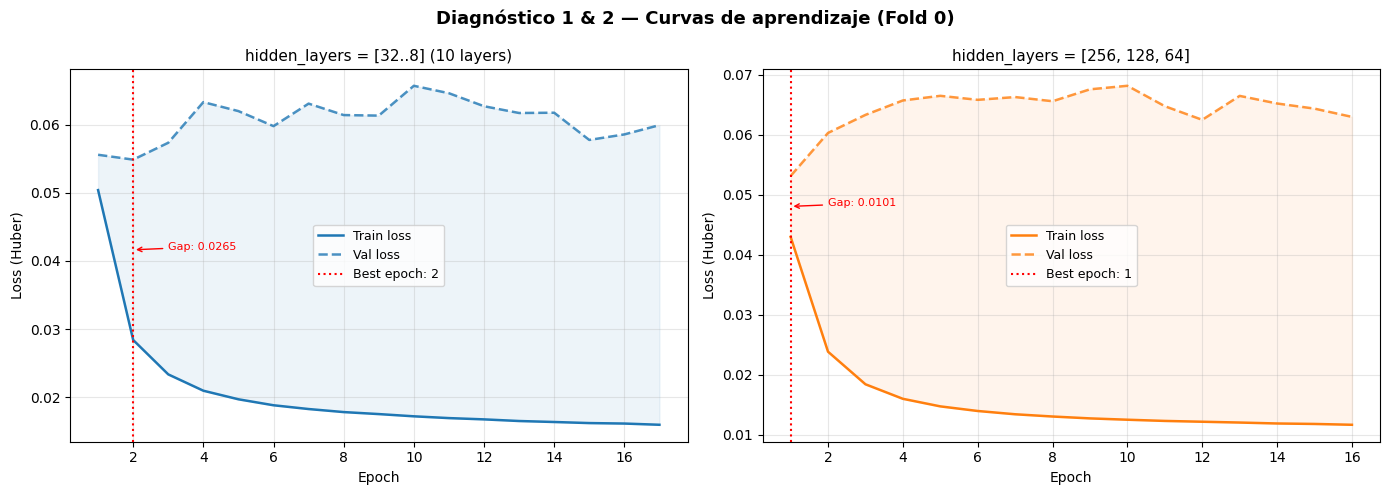

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

configs = [
    (history_current, best_epoch_current, ARCH_CURRENT, axes[0], "tab:blue"),
    (history_reduced, best_epoch_reduced, ARCH_REDUCED,  axes[1], "tab:orange"),
]

for history, best_ep, arch, ax, color in configs:
    train_loss = history["train_loss"]
    val_loss   = history["val_loss"]
    epochs     = range(1, len(train_loss) + 1)

    ax.plot(epochs, train_loss, label="Train loss", color=color, lw=1.8)
    ax.plot(epochs, val_loss,   label="Val loss",   color=color, lw=1.8, linestyle="--", alpha=0.8)
    ax.axvline(best_ep, color="red", linestyle=":", lw=1.5, label=f"Best epoch: {best_ep}")

    # Gap region between train and val at best epoch
    ax.fill_between(epochs, train_loss, val_loss, alpha=0.08, color=color)

    arch_str = str(arch) if len(arch) <= 4 else f"[{arch[0]}..{arch[-1]}] ({len(arch)} layers)"
    ax.set_title(f"hidden_layers = {arch_str}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Huber)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate train/val gap at best epoch
    t_ep = train_loss[best_ep - 1]
    v_ep = val_loss[best_ep - 1]
    gap  = abs(v_ep - t_ep)
    ax.annotate(f"Gap: {gap:.4f}",
                xy=(best_ep, (t_ep + v_ep) / 2),
                xytext=(best_ep + max(1, len(epochs) * 0.04), (t_ep + v_ep) / 2),
                fontsize=8, color="red",
                arrowprops=dict(arrowstyle="->", color="red", lw=1))

fig.suptitle("Diagnóstico 1 & 2 — Curvas de aprendizaje (Fold 0)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Tabla resumen — Métricas y comportamiento de convergencia

In [25]:
def eval_model(model, loader, trs, scaler, device):
    """Evalúa en val y retorna métricas en escala física."""
    y_pred_scaled = model.predict(loader)
    y_true_scaled = []
    for batch in loader:
        y_true_scaled.append(batch[1].numpy())
    y_true_scaled = np.concatenate(y_true_scaled).flatten()

    # Inverse transform
    y_pred_phys = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true_phys = scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

    if trs is not None:
        y_pred_phys = trs.inverse_transform(y_pred_phys)
        y_true_phys = trs.inverse_transform(y_true_phys)

    return compute_metrics(y_true_phys, y_pred_phys)


In [46]:
metrics_current = eval_model(model_current, data_manager.val_loader, val_trs, target_scaler, DEVICE)
metrics_reduced = eval_model(model_reduced,  data_manager.val_loader, val_trs, target_scaler, DEVICE)
metrics_sched   = eval_model(model_sched,  data_manager.val_loader, val_trs, target_scaler, DEVICE)

summary = pd.DataFrame({
    "Arquitectura"      : [f"Actual  ({len(ARCH_CURRENT)} capas)", f"Reducida ({len(ARCH_REDUCED)} capas)", f"Actual + Scheduler"],
    "hidden_layers"     : [str(ARCH_CURRENT), str(ARCH_REDUCED), str(ARCH_CURRENT)],
    "Best epoch"        : [best_epoch_current, best_epoch_reduced, best_epoch_sched],
    "Total epochs run"  : [len(history_current["val_loss"]), len(history_reduced["val_loss"]), len(history_sched["val_loss"])],
    "Train/Val gap (best ep)": [
        abs(history_current["train_loss"][best_epoch_current-1] - history_current["val_loss"][best_epoch_current-1]),
        abs(history_reduced["train_loss"][best_epoch_reduced-1]  - history_reduced["val_loss"][best_epoch_reduced-1]),
        abs(history_sched["train_loss"][best_epoch_sched-1]  - history_sched["val_loss"][best_epoch_sched-1])
    ],
    "R²"   : [metrics_current.get("r2",   float("nan")), metrics_reduced.get("r2",   float("nan")), metrics_sched.get("r2",   float("nan"))],
    "RMSE" : [metrics_current.get("rmse", float("nan")), metrics_reduced.get("rmse", float("nan")), metrics_sched.get("rmse", float("nan"))],
    "MAE"  : [metrics_current.get("mae",  float("nan")), metrics_reduced.get("mae",  float("nan")), metrics_sched.get("mae",  float("nan"))], 
})

pd.set_option("display.float_format", "{:.4f}".format)
display(summary)

,Arquitectura,hidden_layers,Best epoch,Total epochs run,Train/Val gap (best ep),R²,RMSE,MAE
0,Actual (10 capas),"[32, 64, 128, 512, 256, 128, 64, 32, 16, 8]",2,17,0.0265,0.8566,2071.4201,1263.4312
1,Reducida (3 capas),"[256, 128, 64]",1,16,0.0101,0.8419,2174.5395,1384.6118
2,Actual + Scheduler,"[32, 64, 128, 512, 256, 128, 64, 32, 16, 8]",25,40,0.0281,0.8729,1950.1065,1251.1003


In [47]:
metrics_current = eval_model(model_current, data_manager.test_loader, test_trs, target_scaler, DEVICE)
metrics_reduced = eval_model(model_reduced,  data_manager.test_loader, test_trs, target_scaler, DEVICE)
metrics_sched   = eval_model(model_sched,  data_manager.test_loader, test_trs, target_scaler, DEVICE)

summary = pd.DataFrame({
    "Arquitectura"      : [f"Actual  ({len(ARCH_CURRENT)} capas)", f"Reducida ({len(ARCH_REDUCED)} capas)", f"Actual + Scheduler"],
    "hidden_layers"     : [str(ARCH_CURRENT), str(ARCH_REDUCED), str(ARCH_CURRENT)],
    "Best epoch"        : [best_epoch_current, best_epoch_reduced, best_epoch_sched],
    "Total epochs run"  : [len(history_current["val_loss"]), len(history_reduced["val_loss"]), len(history_sched["val_loss"])],
    "Train/Val gap (best ep)": [
        abs(history_current["train_loss"][best_epoch_current-1] - history_current["val_loss"][best_epoch_current-1]),
        abs(history_reduced["train_loss"][best_epoch_reduced-1]  - history_reduced["val_loss"][best_epoch_reduced-1]),
        abs(history_sched["train_loss"][best_epoch_sched-1]  - history_sched["val_loss"][best_epoch_sched-1])
    ],
    "R²"   : [metrics_current.get("r2",   float("nan")), metrics_reduced.get("r2",   float("nan")), metrics_sched.get("r2",   float("nan"))],
    "RMSE" : [metrics_current.get("rmse", float("nan")), metrics_reduced.get("rmse", float("nan")), metrics_sched.get("rmse", float("nan"))],
    "MAE"  : [metrics_current.get("mae",  float("nan")), metrics_reduced.get("mae",  float("nan")), metrics_sched.get("mae",  float("nan"))], 
})

pd.set_option("display.float_format", "{:.4f}".format)
display(summary)

,Arquitectura,hidden_layers,Best epoch,Total epochs run,Train/Val gap (best ep),R²,RMSE,MAE
0,Actual (10 capas),"[32, 64, 128, 512, 256, 128, 64, 32, 16, 8]",2,17,0.0265,0.9393,1592.9680,1178.6483
1,Reducida (3 capas),"[256, 128, 64]",1,16,0.0101,0.8973,2072.1999,1491.9495
2,Actual + Scheduler,"[32, 64, 128, 512, 256, 128, 64, 32, 16, 8]",25,40,0.0281,0.9266,1751.5132,1307.5459
